# Clustering với DBSCAN

Nguồn: https://www.digitalvidya.com/blog/the-top-5-clustering-algorithms-data-scientists-should-know/
![image.png](https://imgur.com/9D6aAF2.gif)

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định
(Cùng dữ liệu giả với `03_Demo-kMeans.ipynb`)

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

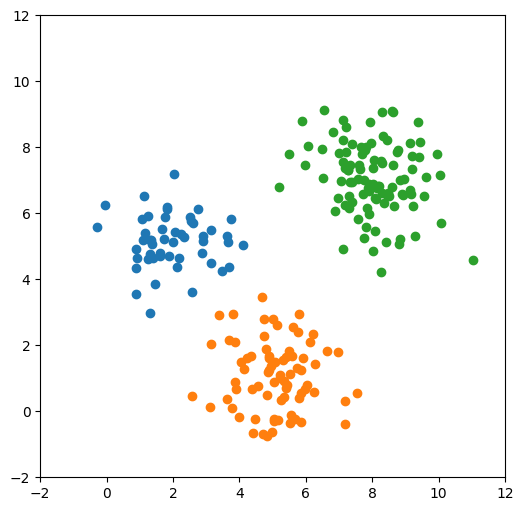

In [4]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập

In [5]:
dat1 = np.stack([x1,y1]).T
dat1.shape

(50, 2)

In [6]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

In [7]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape

(225, 2)

### Sắp ngẫu nhiên các dòng

In [8]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

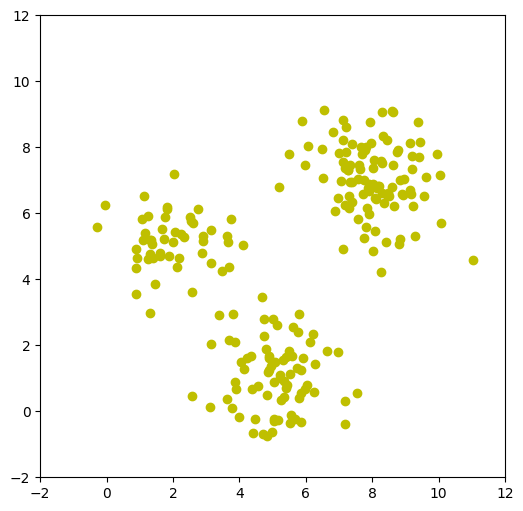

In [9]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm bằng DBSCAN

**=== Import lớp DBSCAN từ thư viện sklearn ===**

In [10]:
from sklearn.cluster import DBSCAN

### 2.1. Khởi tạo model và fit vào dữ liệu

In [11]:
# Giả sử chọn epsilon = 1, minPoints = 5
db = DBSCAN(eps=1, min_samples=5)

**=== Thực hiện fit vào dữ liệu ===**

In [12]:
labels = db.fit_predict(dat)

### 2.2. Kiểm tra kết quả các cluster tìm được

**=== Lấy ra nhãn các clusters ===**

In [13]:
cluster = np.unique(labels)

In [14]:
cluster

array([-1,  0,  1,  2])

**=== Đếm xem mỗi cluster có bao nhiêu điểm ===**

In [15]:
counts = np.unique(labels, return_counts=True)
print(counts)

(array([-1,  0,  1,  2]), array([ 7, 98, 73, 47]))


**=== Hiển thị lên biểu đồ ===**

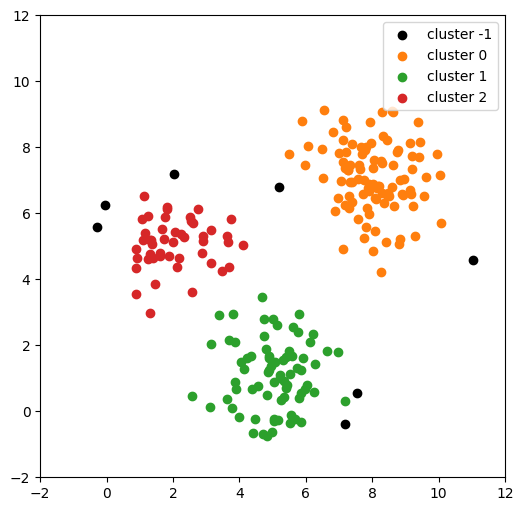

In [16]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
for i, c in enumerate(cluster):
    idx = np.where(labels == c)
    color = colors[i % len(colors)] if c != -1 else 'black'
    plt.scatter(dat[idx,0], dat[idx,1], color=color, label=f'cluster {c}')

plt.legend()
plt.show()

### 2.3. Tính hiệu suất phân cụm

**=== Thử tính với hàm built-in của Sklearn ===**

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
score = silhouette_score(dat, labels)
print(score)

0.639460128792222


**=== Tính lại với các cụm không chứa điểm noise ===**

In [19]:
import pandas as pd

In [20]:
# Bỏ đi các samples bị xác định là noise
dat2 = dat[labels != -1]
cluster2 = labels[labels != -1]

In [21]:
# Tạo một list rỗng để chứa hệ số Silhouette của mỗi sample
s_list = []

for i, sample in enumerate(dat2):
    label = cluster2[i]
    same_cluster = dat2[cluster2 == label]
    other_clusters = np.unique(cluster2[cluster2 != label])

    if len(other_clusters) == 0:
        continue

    intra = np.linalg.norm(same_cluster - sample, axis=1)
    a = np.mean(intra[intra > 0]) if np.sum(intra > 0) > 0 else 0

    dists = []
    for c in other_clusters:
        other = dat2[cluster2 == c]
        d = np.linalg.norm(other - sample, axis=1)
        dists.append(np.mean(d))
    b = np.min(dists)

    s = (b - a) / max(a, b) if max(a, b) > 0 else 0
    s_list.append(s)

In [22]:
silhouette_avg = np.mean(s_list)
print(silhouette_avg)

0.6854228250080899


**==> Thử thực hiện lại mà không bỏ giá trị noise?**